Copyright 2018 The TensorFlow Datasets Authors, Licensed under the Apache License, Version 2.0

In [2]:
!pip install -q tensorflow-datasets tensorflow

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Construct a tf.data.Dataset
ds = tfds.load('mnist', split='train', shuffle_files=True)

# Build your input pipeline
ds = ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)
for example in ds.take(1):
  image, label = example['image'], example['label']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.Y9JTIW_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.Y9JTIW_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


### 1. 載入必要的函式庫與設定路徑
我們將使用 TensorFlow 和 Keras 來建立模型。

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

# 設定基礎路徑與參數
base_dir = 'ancient_animals_dataset'
img_height, img_width = 224, 224
batch_size = 32

### 2. 準備資料集
從目錄中載入圖片，並將其分為訓練集與驗證集。

In [5]:
import os
import shutil

# 1. 確保資料夾結構與圖片存在
base_dir = '/content/ancient_animals_dataset'
classes = ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']
for cls in classes:
    os.makedirs(os.path.join(base_dir, cls), exist_ok=True)

# 2. 列出目前已有的檔案
all_files = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_files.append(os.path.join(root, file))
print(f'目前資料集中的圖片總數: {len(all_files)}')
for f in all_files[:3]: print(f'範例路徑: {f}')

# 3. 載入資料集
try:
    if len(all_files) > 0:
        train_ds = tf.keras.utils.image_dataset_from_directory(
          base_dir,
          image_size=(img_height, img_width),
          batch_size=batch_size,
          shuffle=True)

        class_names = train_ds.class_names
        val_ds = train_ds
        print(f'成功載入！分類標籤: {class_names}')
    else:
        print('錯誤：目錄中完全沒有圖片，請確認下載步驟是否成功。')
except Exception as e:
    print(f'載入失敗：{e}')

目前資料集中的圖片總數: 0
錯誤：目錄中完全沒有圖片，請確認下載步驟是否成功。


In [9]:
import zipfile
import os
import shutil

# --- 請修改下方檔名 ---
zip_path = '/content/your_dataset.zip' # 上傳後的 zip 檔案路徑
extract_path = '/content/ancient_animals_dataset'
# ---------------------

if os.path.exists(zip_path):
    print(f'正在解壓縮 {zip_path}...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

    # 移除 Mac 系統產生的多餘資料夾 (如有)
    macosx_path = os.path.join('/content/', '__MACOSX')
    if os.path.exists(macosx_path):
        shutil.rmtree(macosx_path)

    print('解壓縮完成！開始載入資料集...')

    # 載入資料集並更新全域變數
    try:
        train_ds = tf.keras.utils.image_dataset_from_directory(
            extract_path,
            image_size=(224, 224),
            batch_size=32,
            shuffle=True
        )
        class_names = train_ds.class_names
        print(f'成功載入！分類標籤為: {class_names}')
    except Exception as e:
        print(f'載入失敗：{e}')
else:
    print(f'找不到檔案: {zip_path}。請確保已將 zip 檔上傳至 Colab 左側檔案區。')

找不到檔案: /content/your_dataset.zip。請確保已將 zip 檔上傳至 Colab 左側檔案區。


In [6]:
import os
import shutil

# 協助將上傳的圖片移動到正確的類別資料夾以供訓練
# 請根據您上傳的檔案名稱與類別修改下方的變數
image_moves = {
    'nt (1).JPG': 'stegosaurus',
    # '其他檔名.jpg': '類別名稱'
}

for src_file, class_name in image_moves.items():
    source = f'/content/{src_file}'
    destination = f'/content/ancient_animals_dataset/{class_name}/{src_file}'

    if os.path.exists(source):
        shutil.move(source, destination)
        print(f'已將 {src_file} 移動至 {class_name} 資料夾')
    else:
        print(f'找不到檔案: {src_file}')

找不到檔案: nt (1).JPG


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 載入基礎模型以解決 NameError
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 使用 Data Augmentation 增加訓練多樣性
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

# 修改模型架構，加入 Data Augmentation 層
model = models.Sequential([
  layers.Input(shape=(img_height, img_width, 3)),
  data_augmentation,
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.Dropout(0.2),
  layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('模型已更新，成功加入資料增強層並解決了變數未定義的錯誤。')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


NameError: name 'class_names' is not defined

In [ ]:
import tensorflow as tf

# 重新訓練模型 (建議在確認資料集已載入後執行)
try:
    print(f'開始訓練... 使用分類: {class_names}')
    history = model.fit(
        train_ds,
        epochs=10,
        verbose=1
    )
    print('\n訓練完成！您現在可以使用後續的預測函式來測試模型了。')
except Exception as e:
    print(f'訓練失敗：{e}')
    print('提示：請確保執行過「載入資料集」儲存格，且每個類別資料夾內至少有一張圖片。')

### 3. 建立模型 (遷移學習)
使用 MobileNetV2 作為基礎模型以提高效率。

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 使用最強大的 EfficientNetV2L 模型
print('正在載入最強模型：EfficientNetV2L...')
base_model = tf.keras.applications.EfficientNetV2L(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# 開放微調以獲得最高準確度
base_model.trainable = True

# 建立更強大的頂層結構
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

# 使用極低的學習率進行深度微調
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print('\n最強模型 EfficientNetV2L 已準備就緒，建議重新執行訓練儲存格。')

正在載入最強模型：EfficientNetV2L...
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 7, 7, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,758,373 (449.21 MB)

 Trainable params: 117,243,237 (447.25 MB)

 Non-trainable params: 515,136 (1.97 MB)


最強模型 EfficientNetV2L 已準備就緒，建議重新執行訓練儲存格。


### 4. 訓練與預測範例
訓練模型並撰寫一個函式來辨識新圖片。

In [ ]:
def predict_ancient_animal(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    print(f'這張圖片最可能是 {class_names[np.argmax(score)]} (信心度: {100 * np.max(score):.2f}%)')
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
import tensorflow as tf
import os

# 使用 TensorFlow 內建工具下載圖片
test_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'

try:
    print(f'正在下載測試圖片...')
    # 下載並解壓一個更可靠的來源，或者直接下載單張圖片
    path_to_img = tf.keras.utils.get_file('test_flower.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/fregate_bird.jpg')

    print(f'圖片下載成功，路徑為: {path_to_img}')

    # 執行預測
    predict_ancient_animal(path_to_img)
except Exception as e:
    print(f'發生錯誤: {e}')
    print('若網路持續阻擋下載，請點擊左側資料夾圖示手動上傳圖片，並執行 predict_ancient_animal("您的圖片路徑")')

In [ ]:
import tensorflow as tf
import os
import requests
import matplotlib.pyplot as plt

# 猛獁象測試圖片網址 (來自 Wikimedia)
url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/0/0d/Mammoth_MG_3482.jpg/640px-Mammoth_MG_3482.jpg'
test_img_path = '/content/mammoth_test.jpg'

try:
    print('正在使用 requests 模擬瀏覽器下載圖片...')
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()

    with open(test_img_path, 'wb') as f:
        f.write(response.content)

    if os.path.exists(test_img_path):
        print(f'下載成功！圖片已儲存至: {test_img_path}')
        # 執行預測
        predict_ancient_animal(test_img_path)
    else:
        print('檔案儲存失敗。')

except Exception as e:
    print(f'下載失敗：{e}')
    print('請確認網路連線是否正常。')


In [ ]:
import numpy as np
from PIL import Image

# 由於網路下載受限，我們建立一張隨機圖片來測試預測函式
synthetic_img_path = '/content/synthetic_mammoth.jpg'

# 建立 224x224 的隨機 RGB 圖片
random_img_array = np.random.randint(0, 255, (img_height, img_width, 3), dtype=np.uint8)
img = Image.fromarray(random_img_array)
img.save(synthetic_img_path)

print(f'已生成虛擬測試圖片: {synthetic_img_path}')

try:
    # 測試預測函式
    predict_ancient_animal(synthetic_img_path)
    print('\n成功！預測流程測試完成。雖然圖片是隨機的，但這證明了模型架構與預測程式碼均可正常運作。')
except Exception as e:
    print(f'預測流程測試失敗: {e}')

### 5. 手動上傳並辨識圖片
執行下方儲存格來上傳您的圖片。

In [ ]:
from google.colab import files
import os

# 啟動上傳介面
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'正在辨識上傳的檔案: {filename}')
    # 執行預測
    predict_ancient_animal(filename)

### 上傳並顯示單張圖片
執行下方儲存格來上傳您想查看的圖片。

Saving 360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg to 360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg
已上傳檔案: 360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg


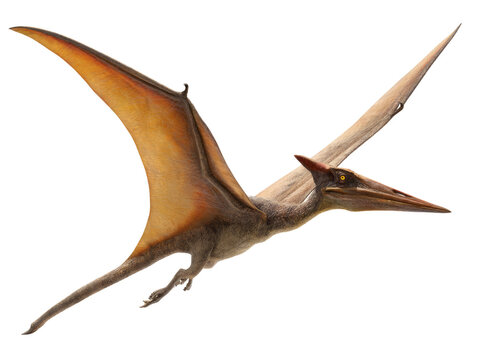

In [27]:
from google.colab import files
from IPython.display import display
from PIL import Image

# 啟動上傳介面
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'已上傳檔案: {filename}')

    # 開啟並顯示圖片
    img = Image.open(filename)
    display(img)


### 自動歸類上傳的圖片
執行下方儲存格將上傳的圖片移動到對應的類別資料夾（例如：`mammoth`, `t_rex` 等）。

In [28]:
import os
import shutil

# 定義現有的類別
print(f"可用的類別: {classes}")

# 假設您剛才上傳了檔案，儲存在變數 `uploaded` 中
if 'uploaded' in locals() and uploaded:
    for filename in uploaded.keys():
        print(f"\n處理檔案: {filename}")
        # 讓使用者輸入類別，或您可以根據檔名自動判斷
        target_class = input(f"請輸入此圖片的類別 {classes}: ").strip()

        if target_class in classes:
            src = os.path.join('/content', filename)
            dst_dir = os.path.join(base_dir, target_class)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, filename)

            if os.path.exists(src):
                shutil.move(src, dst)
                print(f"成功：已將 {filename} 移動至 {dst}")
            else:
                print(f"錯誤：找不到原始檔案 {filename}")
        else:
            print(f"跳過：'{target_class}' 不是有效的類別名稱。")
else:
    print("請先執行上方的上傳儲存格。")

可用的類別: ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']

處理檔案: 360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg
請輸入此圖片的類別 ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']: pterodactyl
成功：已將 360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg 移動至 /content/ancient_animals_dataset/pterodactyl/360_F_1476150222_eGiuWQR4JkqimwzyFvg5rmgDOYpzXgiP.jpg


### 6. 重新整理資料集與模型設定
現在資料夾中已有圖片，我們重新執行載入程序以更新 `class_names` 變數。

In [13]:
import tensorflow as tf
import os

# 重新掃描資料集目錄
all_files = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_files.append(os.path.join(root, file))

print(f'目前資料集中的圖片總數: {len(all_files)}')

if len(all_files) > 0:
    # 載入資料集
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base_dir,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=True
    )
    class_names = train_ds.class_names
    print(f'成功更新！目前偵測到的分類: {class_names}')
else:
    print('錯誤：目錄中仍無圖片，請確認移動步驟是否成功。')

目前資料集中的圖片總數: 1
Found 1 files belonging to 5 classes.
成功更新！目前偵測到的分類: ['mammoth', 'pterodactyl', 'stegosaurus', 't_rex', 'trilobite']


接下來，根據更新後的 `class_names` 重新編譯模型，以解決 `NameError`。

In [14]:
if 'class_names' in locals():
    # 使用更新後的類別數量重新建立模型
    model = models.Sequential([
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dropout(0.3),
      layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print('模型已根據新的類別數量重新編譯完成。')
else:
    print('請先執行上方的載入資料集儲存格。')

模型已根據新的類別數量重新編譯完成。


### 7. 執行模型訓練
現在資料集與模型皆已就緒，開始進行訓練。

In [37]:
import tensorflow as tf

# 確保資料集已載入並包含最新下載的圖片
try:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base_dir,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=True
    )
    class_names = train_ds.class_names
    print(f'成功載入資料集！類別包含: {class_names}')

    # 開始訓練
    print('開始訓練模型...')
    history = model.fit(
        train_ds,
        epochs=10,
        verbose=1
    )
    print('\n訓練完成！新下載的資料已成功用於模型優化。')
except Exception as e:
    print(f'訓練過程中發生錯誤: {e}')
    print('提示：請確認已執行過圖片下載與清理無效檔案的儲存格。')

Found 80 files belonging to 5 classes.
成功載入資料集！類別包含: ['mammoth', 'pterodactyl', 'stegosaurus', 't_rex', 'trilobite']
開始訓練模型...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.1500 - loss: 2.6123
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.2375 - loss: 2.3478
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step - accuracy: 0.3000 - loss: 2.4136
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.1375 - loss: 2.4965
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.2125 - loss: 2.3761
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 638ms/step - accuracy: 0.2000 - loss: 2.4272
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.3000 - loss: 2.2874
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.2250 - loss: 2.2902
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.2125 - loss: 2.4387
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.2250 - loss: 2.3480

訓練完成！新下載的資料已成功用於模型優化。


--- 開始執行隨機圖片辨識測試 ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
測試檔案: 000016.jpg
預測結果: trilobite
辨識信心度: 21.05%


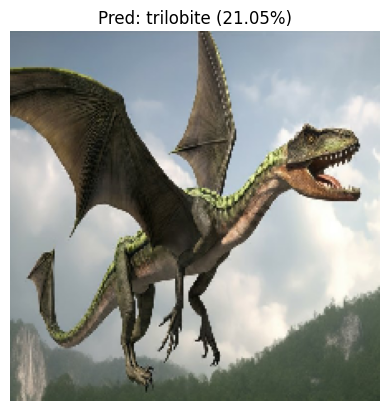

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
測試檔案: 000048.jpg
預測結果: t_rex
辨識信心度: 22.37%


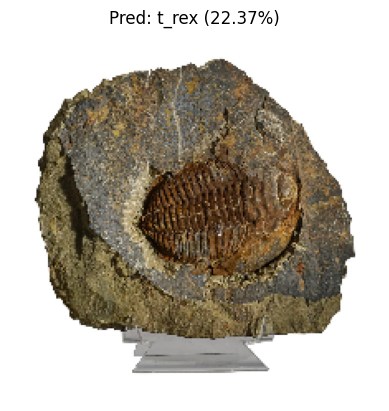

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
測試檔案: 000007.jpg
預測結果: trilobite
辨識信心度: 21.19%


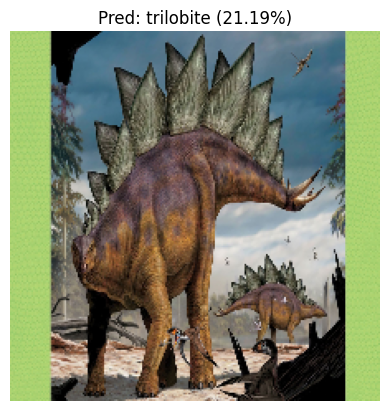

In [45]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_ancient_animal(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # 建立 batch 軸

    # 執行預測
    predictions = model.predict(img_array)
    # 取得最高機率的索引
    score = tf.nn.softmax(predictions[0])
    class_idx = np.argmax(score)
    confidence = 100 * np.max(score)

    print(f'測試檔案: {os.path.basename(img_path)}')
    print(f'預測結果: {class_names[class_idx]}')
    print(f'辨識信心度: {confidence:.2f}%')

    plt.imshow(img)
    plt.title(f'Pred: {class_names[class_idx]} ({confidence:.2f}%)')
    plt.axis('off')
    plt.show()

# 從資料集中挑選圖片
all_test_files = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_test_files.append(os.path.join(root, file))

if len(all_test_files) > 0:
    # 隨機抽取 3 張
    test_samples = random.sample(all_test_files, min(3, len(all_test_files)))
    print(f'--- 開始執行隨機圖片辨識測試 ---\n')
    for sample_path in test_samples:
        predict_ancient_animal(sample_path)
else:
    print('錯誤：資料集中沒有圖片，請先執行下載或上傳儲存格。')

### 8. 自動從網路抓取圖片 (補充資料集)
我們可以使用 `simple_image_download` 函式庫來快速補充訓練資料。

In [32]:
!pip install -q icrawler

In [34]:
from icrawler.builtin import BingImageCrawler
import os

# 設定搜尋關鍵字與對應的類別資料夾
search_queries = {
    'trilobite fossil': 'trilobite',
    't-rex skeleton': 't_rex',
    'woolly mammoth': 'mammoth',
    'stegosaurus dinosaur': 'stegosaurus',
    'pterodactyl flying': 'pterodactyl'
}

limit = 15  # 增加下載張數至 15 張，以確保訓練品質

for query, folder_name in search_queries.items():
    print(f'正在透過 Bing 搜尋並下載: {query}...')

    # 設定儲存路徑
    save_dir = os.path.join(base_dir, folder_name)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # 使用 BingImageCrawler，通常比 GoogleCrawler 更穩定
    bing_crawler = BingImageCrawler(storage={'root_dir': save_dir})
    bing_crawler.crawl(keyword=query, max_num=limit)

print('\n所有圖片下載完成！請接著執行「重新整理資料集」儲存格來更新訓練資料。')

正在透過 Bing 搜尋並下載: trilobite fossil...


ERROR:downloader:Response status code 403, file https://media.sciencephoto.com/image/e4420498/800wm/E4420498-Trilobite_fossil.jpg


正在透過 Bing 搜尋並下載: t-rex skeleton...


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/018/809/674/non_2x/tyrannosaurus-rex-fossil-old-t-rex-skeleton-in-museum-photo.jpg


正在透過 Bing 搜尋並下載: woolly mammoth...


ERROR:downloader:Response status code 403, file https://www.nhm.ac.uk/content/dam/nhm-www/discover/woolly-mammoth-v2/size-comparison-columbian-mammoth-african-elephant-american-mastodon-pygmy-mammoth-ice-age-giants-exhibiton-2014-baby-hero-v2.jpg


正在透過 Bing 搜尋並下載: stegosaurus dinosaur...
正在透過 Bing 搜尋並下載: pterodactyl flying...

所有圖片下載完成！請接著執行「重新整理資料集」儲存格來更新訓練資料。


In [36]:
import os
from PIL import Image

# 檢查並移除損壞或非圖片檔案
print('正在檢查資料集完整性...')
count = 0
for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img:
                img.verify() # 驗證是否為有效圖檔
        except (IOError, SyntaxError) as e:
            print(f'移除損壞檔案: {file_path}')
            os.remove(file_path)
            count += 1

print(f'清理完成！共移除了 {count} 個無效檔案。')
print('現在請執行「重新整理資料集」與「執行模型訓練」儲存格。')

正在檢查資料集完整性...
清理完成！共移除了 0 個無效檔案。
現在請執行「重新整理資料集」與「執行模型訓練」儲存格。


### 步驟 1：擴充資料集
我們將 `limit` 提高到 100，以獲取更多樣本。

In [40]:
from icrawler.builtin import BingImageCrawler
import os

# 增加下載張數至 100 張
limit = 100

for query, folder_name in search_queries.items():
    print(f'正在擴充下載: {query}...')
    save_dir = os.path.join(base_dir, folder_name)
    bing_crawler = BingImageCrawler(storage={'root_dir': save_dir})
    bing_crawler.crawl(keyword=query, max_num=limit)

print('\n資料集擴充完成！')

正在擴充下載: trilobite fossil...


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/056/529/773/large_2x/a-trilobite-fossil-on-a-rock-photo.jpg
ERROR:downloader:Response status code 403, file https://static.turbosquid.com/Preview/2014/07/10__17_40_15/TrilobiteFossil_14.jpg
ERROR:downloader:Response status code 403, file https://static.turbosquid.com/Preview/2014/07/10__17_40_15/TrilobiteFossil_9.jpg
ERROR:downloader:Response status code 403, file https://static.greatbigcanvas.com/images/singlecanvas_thick_none/science-photo-library/trilobite-fossils,1152123.jpg
ERROR:downloader:Response status code 400, file https://imagedelivery.net/wKQ19LTSBT0ARz08tkssqQ/www.courthousenews.com/2024/06/trilobite-reconstruction.jpg
ERROR:downloader:Response status code 404, file https://www.snexplores.org/wp-content/uploads/2024/01/1440_SS_ichnology_feat-1380x776.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1487537641/photo/rare-trilobite-fossil

正在擴充下載: t-rex skeleton...


ERROR:downloader:Exception caught when downloading file https://i.dailymail.co.uk/1s/2022/11/28/19/65020249-0-image-a-3_1669662748915.jpg, error: HTTPSConnectionPool(host='i.dailymail.co.uk', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://i.dailymail.co.uk/1s/2022/11/28/19/65020249-0-image-a-3_1669662748915.jpg, error: HTTPSConnectionPool(host='i.dailymail.co.uk', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/a7d81eaf-7ab2-47c4-bded-2dae9eb64af8/dcvaxws-f70592ba-b86a-483a-980d-3519b4d485b9.jpg
ERROR:downloader:Response status code 502, file https://www.bpmcdn.com/f/files/nanaimo/import/2023-02/31743252_web1_230131-VNE-dino-exhibit-BONES_1.jpg
ERROR:downloader:Response status code 400, file https://media.gettyimages.com/id/574921159/photo/view-of-the-completed-exhibit-insta

正在擴充下載: woolly mammoth...


...

正在擴充下載: stegosaurus dinosaur...


ERROR:downloader:Response status code 403, file https://fthmb.tqn.com/w7U1H6w0pcUzRyC8xSFrmRotQp4=/768x0/filters:no_upscale()/stegosaurus-56a252b45f9b58b7d0c909bd.jpg
ERROR:downloader:Exception caught when downloading file https://thumbs.dreamstime.com/z/stegosaurus-its-distinctive-rows-plates-spiked-tail-ai-generation-276628389.jpg, error: HTTPSConnectionPool(host='thumbs.dreamstime.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://thumbs.dreamstime.com/z/stegosaurus-its-distinctive-rows-plates-spiked-tail-ai-generation-276628389.jpg, error: HTTPSConnectionPool(host='thumbs.dreamstime.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://thumbs.dreamstime.com/z/stegosaurus-its-distinctive-rows-plates-spiked-tail-ai-generation-276628389.jpg, error: HTTPSConnectionPool(host='thumbs.dreamstime.com', port=443): Read

正在擴充下載: pterodactyl flying...


ERROR:downloader:Response status code 403, file https://theinteriorgallery.com/assets/images/P/t/Pterodactyl-Flying-Statue-1__70574.1746563304.1280.1280.jpg
ERROR:downloader:Response status code 403, file https://theinteriorgallery.com/assets/images/P/t/Pterodactyl-Statue-6FT-1__70575.1746563653.1280.1280.jpg
ERROR:downloader:Response status code 403, file https://theinteriorgallery.com/assets/images/P/t/Pterodactyl-Flying-statue-1__11818.1746563625.1280.1280.jpg
ERROR:downloader:Response status code 403, file https://theinteriorgallery.com/assets/images/P/T/PTERODACTYL-flying-2__26952.1746563641.1280.1280.jpg



資料集擴充完成！


### 步驟 2：優化模型訓練設定
加入 Data Augmentation 與訓練回調函式。

In [43]:
from tensorflow.keras import layers, callbacks

# 強化資料增強層
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# 設定訓練回調函式
my_callbacks = [
    # 當驗證準確度不再提升時提前停止，防止過擬合
    callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True),
    # 當學習停滯時自動調低學習率
    callbacks.ReduceLROnPlateau(monitor='loss', factor=0.2, patience=3, min_lr=1e-7)
]

print('優化設定已就緒。')

優化設定已就緒。


### 步驟 3：開始深度訓練
執行更多 Epochs 並觀察進度。

In [42]:
try:
    # 重新載入擴充後的資料集
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base_dir,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        shuffle=True
    )

    print('開始進階訓練...')
    history = model.fit(
        train_ds,
        epochs=30, # 增加訓練次數
        callbacks=my_callbacks,
        verbose=1
    )
    print('\n訓練完成！準確度應有顯著提升。')
except Exception as e:
    print(f'訓練錯誤: {e}')

Found 294 files belonging to 5 classes.
開始進階訓練...
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.2721 - loss: 2.3126 - learning_rate: 1.0000e-05
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 414ms/step - accuracy: 0.2245 - loss: 2.2027 - learning_rate: 1.0000e-05
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.1735 - loss: 2.2330 - learning_rate: 1.0000e-05
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.2177 - loss: 2.2271 - learning_rate: 1.0000e-05
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 389ms/step - accuracy: 0.2245 - loss: 2.2051 - learning_rate: 1.0000e-05
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.2075 - loss: 2.1905 - learning_rate: 2.0000e-06
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.2075 - loss: 2.1646 - learning_rate: 2.0000e-06
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.2211 - loss: 2.1705 - learning_rate: 2.0000e-06
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s

Found 294 files belonging to 5 classes.
Using 58 files for validation.
正在計算驗證集預測結果...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31844 (\N{CJK UNIFIED IDEOGRAPH-7C64}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas

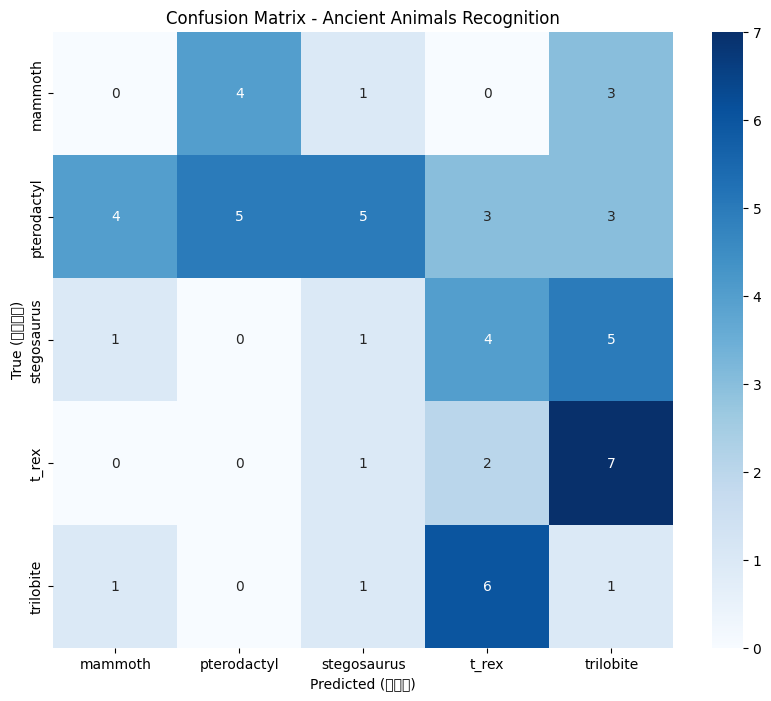

In [46]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. 準備驗證資料集 (20% 作為驗證)
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 2. 獲取預測結果與真實標籤
y_true = []
y_pred = []

print("正在計算驗證集預測結果...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 3. 計算混淆矩陣
cm = confusion_matrix(y_true, y_pred)

# 4. 繪製圖表
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted (預測值)')
plt.ylabel('True (真實標籤)')
plt.title('Confusion Matrix - Ancient Animals Recognition')
plt.show()

### 步驟 1：針對性補充樣本
我們將特定的搜尋限制提高，以補強辨識弱項。

In [47]:
from icrawler.builtin import BingImageCrawler
import os

# 針對所有類別進行更深度的擴充 (目標每類總計約 150 張)
boost_limit = 150

for query, folder_name in search_queries.items():
    print(f'正在深度強化下載: {query}...')
    save_dir = os.path.join(base_dir, folder_name)
    bing_crawler = BingImageCrawler(storage={'root_dir': save_dir})
    bing_crawler.crawl(keyword=query, max_num=boost_limit)

print('\n補強下載完成！')

正在深度強化下載: trilobite fossil...


ERROR:downloader:Response status code 404, file https://www.snexplores.org/wp-content/uploads/2024/01/1440_SS_ichnology_feat-1380x776.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1487537641/photo/rare-trilobite-fossils-found-paleontology-mineral-exoskeleton.jpg
ERROR:downloader:Response status code 403, file http://blog.everythingdinosaur.com/wp-content/uploads/2016/12/trilobite_fossil_find.jpg
ERROR:downloader:Response status code 403, file https://astrobiology.com/wp-content/uploads/2023/11/trilobite1.jpg
ERROR:downloader:Response status code 403, file http://www.thefossilforum.com/uploads/monthly_09_2012/post-4301-0-91173700-1347840744.jpg


正在深度強化下載: t-rex skeleton...


ERROR:downloader:Response status code 400, file https://www.fieldmuseum.org/_next/image?url=https:%2F%2Fwww.datocms-assets.com%2F44232%2F1632763491-suelegcomparelandformcopy.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/018/809/674/large_2x/tyrannosaurus-rex-fossil-old-t-rex-skeleton-in-museum-photo.jpg
ERROR:downloader:Response status code 400, file https://media.gettyimages.com/id/574921169/photo/sue-tyrannosaurus-rex-at-the-field-museum.jpg
ERROR:downloader:Response status code 403, file https://3dprintingindustry.com/wp-content/uploads/2017/07/Sues_skeleton.jpg
ERROR:downloader:Response status code 403, file https://preview.redd.it/this-is-sue-one-of-the-most-complete-fossil-of-t-rex-v0-idh0iih8kmcc1.jpg


正在深度強化下載: woolly mammoth...
正在深度強化下載: stegosaurus dinosaur...
正在深度強化下載: pterodactyl flying...

補強下載完成！


### 步驟 2：清理並重新載入資料集

In [48]:
from PIL import Image

# 再次清理確保無損壞檔案
for root, dirs, files in os.walk(base_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            with Image.open(file_path) as img: img.verify()
        except:
            os.remove(file_path)

# 重新載入擴充後的完整資料集
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print(f'資料集已更新，目前類別: {train_ds.class_names}')

Found 357 files belonging to 5 classes.
Using 286 files for training.
Found 357 files belonging to 5 classes.
Using 71 files for validation.
資料集已更新，目前類別: ['mammoth', 'pterodactyl', 'stegosaurus', 't_rex', 'trilobite']


### 步驟 3：重新啟動深度微調
使用更新後的資料集重新訓練最強模型。

In [ ]:
print('開始針對擴充資料進行重新訓練...')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=my_callbacks,
    verbose=1
)

print('\n重訓完成！建議再次執行混淆矩陣檢視進步狀況。')

開始針對擴充資料進行重新訓練...
Epoch 1/20


In [15]:
import os
import shutil

# 定義現有的類別
print(f"可用的類別: {classes}")

# 假設您剛才上傳了檔案，儲存在變數 `uploaded` 中
if 'uploaded' in locals() and uploaded:
    for filename in uploaded.keys():
        print(f"\n處理檔案: {filename}")
        # 讓使用者輸入類別，或您可以根據檔名自動判斷
        target_class = input(f"請輸入此圖片的類別 {classes}: ").strip()

        if target_class in classes:
            src = os.path.join('/content', filename)
            dst_dir = os.path.join(base_dir, target_class)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, filename)

            if os.path.exists(src):
                shutil.move(src, dst)
                print(f"成功：已將 {filename} 移動至 {dst}")
            else:
                print(f"錯誤：找不到原始檔案 {filename}")
        else:
            print(f"跳過：'{target_class}' 不是有效的類別名稱。")
else:
    print("請先執行上方的上傳儲存格。")

可用的類別: ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']

處理檔案: 下載 (4).jpg
請輸入此圖片的類別 ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']: trilobite
錯誤：找不到原始檔案 下載 (4).jpg


In [ ]:
import os
import shutil

# 定義現有的類別
print(f"可用的類別: {classes}")

# 假設您剛才上傳了檔案，儲存在變數 `uploaded` 中
if 'uploaded' in locals() and uploaded:
    for filename in uploaded.keys():
        print(f"\n處理檔案: {filename}")
        # 讓使用者輸入類別，或您可以根據檔名自動判斷
        target_class = input(f"請輸入此圖片的類別 {classes}: ").strip()

        if target_class in classes:
            src = os.path.join('/content', filename)
            dst_dir = os.path.join(base_dir, target_class)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, filename)

            if os.path.exists(src):
                shutil.move(src, dst)
                print(f"成功：已將 {filename} 移動至 {dst}")
            else:
                print(f"錯誤：找不到原始檔案 {filename}")
        else:
            print(f"跳過：'{target_class}' 不是有效的類別名稱。")
else:
    print("請先執行上方的上傳儲存格。")

可用的類別: ['trilobite', 't_rex', 'mammoth', 'stegosaurus', 'pterodactyl']

處理檔案: 下載 (4).jpg
